### 1. Quelle est la fonction de perte utilisée ?

Dans un problème de classification binaire, la fonction de perte classique utilisée est la **perte 0-1**. Elle est définie de la manière suivante :

$$
l(y, \hat{y}) = 
\begin{cases} 
1, & \text{si} \ y \neq \hat{y} \\
0, & \text{si} \ y = \hat{y} 
\end{cases}
$$

Cette fonction de perte pénalise les erreurs de prédiction en attribuant une valeur de 1 lorsqu'une prédiction est incorrecte, et 0 sinon.

### 2. Définition du risque moyen dans un problème de discrimination binaire

Le **risque moyen** dans un problème de classification est la probabilité moyenne de faire une erreur de prédiction. Il est défini par :

$$
R(f) = \mathbb{E}[l(Y, \hat{f}_{D_n}(X))]
$$

où $l(Y, f(X))$ est la fonction de perte, et $f(X)$ est la prédiction faite par le modèle pour l'entrée $ X $. En d'autres termes, le risque moyen est l'espérance de la perte pour l'ensemble des observations.

Avec la perte 0-1,le risque moyen correspond alors au taux d'erreur moyen du modèle.

### 3. Calcul de la règle de Bayes $ g^* $

La **règle de Bayes** est définie comme la fonction de prédiction qui maximise la probabilité conditionnelle :
$$
g^*(x) = \arg\max_{y \in \{0, 1\}} P(Y = y | X = x)
$$
Autrement dit, $ g^*(x) $ prédit $ Y = 1 $ si $ P(Y = 1 | X = x) > P(Y = 0 | X = x) $, sinon elle prédit $ Y = 0 $.

# Part 1 — Règle de Bayes et risque en classification binaire

On considère une classification binaire avec une fonction de perte **0–1** :

$$
L(y,\hat y)=\mathbf{1}_{\{y\neq \hat y\}}.
$$

On note

$$
\eta(x)=P(Y=1\mid X=x)
$$

la **probabilité a posteriori** de la classe $1$.

La règle de Bayes consiste à choisir la classe ayant la plus grande probabilité conditionnelle :

$$
g^*(x)
=
\begin{cases}
1 & \text{si } \eta(x)>\frac12,\\
0 & \text{si } \eta(x)\leq \frac12.
\end{cases}
$$
L'**erreur de Bayes ou risque de Bayes** correspond au risque minimal que l'on peut atteindre avec la règle optimale $ g^*(x) $. Elle représente la probabilité de se tromper même avec la règle de décision optimale :
$$
\text{Erreur de Bayes} = \mathbb{P}(Y \neq g^*(X))
$$

Le **risque de Bayes** est alors

$$
R^*
=
\inf_g R(g)
=
E\left[\min\{\eta(X),1-\eta(X)\}\right].
$$

Une autre expression fondamentale est

$$
\boxed{
R^*
=
\frac12-E\left[\left|\eta(X)-\frac12\right|\right]
}
$$

qui pourrait être utile pour comparer la difficulté des différents problèmes.

### 1. Cas 1

#### 1.1. Modèle

On suppose $X\sim\mathcal N(0,1)$ et $U\sim\mathcal U[0,1]$, indépendants, et

$$
Y=
\begin{cases}
\mathbf 1(U\leq 0.1), & \text{si } X\leq 0,\\[2mm]
\mathbf 1(U>0.2), & \text{si } X>0.
\end{cases}
$$

On cherche

$$
\eta(x)=P(Y=1\mid X=x).
$$

##### Lorsque $x\leq 0$

On a

$$
Y=1\iff U\leq 0.1.
$$

Donc

$$
\eta(x)
=
P(U\leq 0.1)
=
0.1.
$$

##### Lorsque $x>0$

On a

$$
Y=1\iff U>0.2.
$$

Comme $U\sim\mathcal U[0,1]$,

$$
\eta(x)
=
P(U>0.2)
=
1-0.2
=
0.8.
$$

Ainsi,

$$
\boxed{
\eta(x)=
\begin{cases}
0.1,&x\leq0,\\
0.8,&x>0.
\end{cases}
}
$$

### 1.2. Règle de Bayes

La règle de Bayes prédit $1$ lorsque

$$
\eta(x)>\frac12.
$$

Pour $x\leq0$,

$$
\eta(x)=0.1<0.5
$$

donc on prédit $0$.

Pour $x>0$,

$$
\eta(x)=0.8>0.5
$$

donc on prédit $1$.

La règle de Bayes est donc

$$
\boxed{
g^*(x)=
\begin{cases}
0,&x\leq0,\\
1,&x>0.
\end{cases}
}
$$

La frontière de décision est

$$
\boxed{x=0}.
$$

### 1.3. Calcul du risque de Bayes

Le risque conditionnel de Bayes vaut

$$
\min\{\eta(x),1-\eta(x)\}.
$$

Pour $x\leq0$,

$$
\min(0.1,0.9)=0.1.
$$

Autrement dit, la règle de Bayes prédit $ Y = 0 $, mais $ Y = 1 $ avec une probabilité de 0.1. L'erreur dans cette région est donc de 0.1.

Pour $x>0$,

$$
\min(0.8,0.2)=0.2.
$$

Ici, la règle de Bayes prédit $ Y = 1 $, mais $ Y = 0 $ avec une probabilité de 0.2. L'erreur dans cette région est donc de 0.2.

Or, puisque $X\sim\mathcal N(0,1)$,

$$
P(X\leq0)=P(X>0)=\frac12.
$$

On obtient donc

$$
R^*
=
\frac12(0.1)+\frac12(0.2).
$$

Ainsi,

$$
\boxed{R_1^*=0.15}.
$$

Autrement dit, même le meilleur classifieur possible commet en moyenne au moins

$$
\boxed{15\%}
$$

d'erreurs. Cette erreur est **irréductible** avec les variables disponibles.

### 2. Cas 2

#### 2.1. Modèle

On a maintenant

$$
Y=
\begin{cases}
\mathbf 1(U\leq0.2),&X\leq0,\\[2mm]
\mathbf 1(U>0.4),&X>0.
\end{cases}
$$

##### Lorsque $x\leq0$

$$
\eta(x)
=
P(Y=1\mid X=x)
=
P(U\leq0.2)
=
0.2.
$$

##### Lorsque $x>0$

$$
\eta(x)
=
P(Y=1\mid X=x)
=
P(U>0.4)
=
0.6.
$$

Donc

$$
\boxed{
\eta(x)=
\begin{cases}
0.2,&x\leq0,\\
0.6,&x>0.
\end{cases}
}
$$

### 2.2. Règle de Bayes

Pour $x\leq0$,

$$
\eta(x)=0.2<0.5,
$$

donc

$$
g^*(x)=0.
$$

Pour $x>0$,

$$
\eta(x)=0.6>0.5,
$$

donc

$$
g^*(x)=1.
$$

La règle de Bayes est donc exactement la même frontière que dans le cas 1 :

$$
\boxed{
g^*(x)=
\begin{cases}
0,&x\leq0,\\
1,&x>0.
\end{cases}
}
$$

### 2.3. Risque de Bayes

Pour $x\leq0$,

$$
\min(0.2,0.8)=0.2.
$$

Pour $x>0$,

$$
\min(0.6,0.4)=0.4.
$$

Comme

$$
P(X\leq0)=P(X>0)=\frac12,
$$

on obtient

$$
R^*
=
\frac12(0.2)+\frac12(0.4)
=
0.3.
$$

Donc

$$
\boxed{R_2^*=0.30}.
$$

Le meilleur classifieur possible commet donc encore

$$
\boxed{30\%}
$$

d'erreurs.

### 3. Cas 3

On dispose cette fois d'une variable explicative qualitative :

$$
X\in\{\text{Femme},\text{Homme}\}.
$$

On définit $Y=1$ lorsque le café est **sucré**.

Les informations disponibles sont

$$
P(Y=1\mid X=\text{Femme})=0.20
$$

et

$$
P(Y=1\mid X=\text{Homme})=0.10.
$$

### 3.1. Probabilité a posteriori

Dans ce cas,

$$
\eta(x)=P(Y=1\mid X=x)
$$

vaut

$$
\boxed{
\eta(x)=
\begin{cases}
0.20,&x=\text{Femme},\\
0.10,&x=\text{Homme}.
\end{cases}
}
$$

Dans les deux cas,

$$
\eta(x)<0.5.
$$

### 3.2. Règle de Bayes

La règle de Bayes consiste à prédire $Y=1$ lorsque

$$
P(Y=1\mid X=x)>0.5.
$$

Or :

$$
P(Y=1\mid X=\text{Femme})=0.20<0.5
$$

et

$$
P(Y=1\mid X=\text{Homme})=0.10<0.5.
$$

Par conséquent, le meilleur classifieur est simplement

$$
\boxed{
g^*(x)=0
\qquad\forall x.
}
$$

Autrement dit :

> **La règle de Bayes prédit toujours “café non sucré”, quel que soit le sexe du consommateur.**

Ce résultat est très important pédagogiquement : une variable $X$ peut avoir une relation statistique avec $Y$ sans être suffisamment informative pour modifier la décision de Bayes sous une perte $0$-$1$.

### 3.3. Risque de Bayes

Pour une femme, le risque conditionnel est

$$
\min(0.20,0.80)=0.20.
$$

Pour un homme, il vaut

$$
\min(0.10,0.90)=0.10.
$$

Notons

$$
\pi=P(X=\text{Femme}).
$$

Alors

$$
P(X=\text{Homme})=1-\pi.
$$

Le risque de Bayes vaut donc

$$
R_3^*
=
\pi(0.20)+(1-\pi)(0.10).
$$

En développant :

$$
R_3^*
=
0.20\pi+0.10-0.10\pi
$$

d'où

$$
\boxed{
R_3^*=0.10+0.10\pi.
}
$$

### 3.4. Peut-on donner une valeur numérique ?

**Non, pas avec les informations fournies.**

Il manque la proportion de femmes dans l'échantillon, c'est-à-dire

$$
P(X=\text{Femme}).
$$

On peut cependant obtenir une borne :

$$
0\leq\pi\leq1.
$$

Donc

$$
\boxed{
0.10\leq R_3^*\leq0.20.
}
$$

Par exemple, si l'échantillon contient autant de femmes que d'hommes,

$$
\pi=0.5,
$$

alors

$$
R_3^*
=
0.10+0.10(0.5)
=
0.15.
$$

Dans ce cas particulier,

$$
\boxed{R_3^*=0.15}.
$$

De manière générale, si l'on connaît les nombres de femmes $n_F$ et d'hommes $n_H$, avec

$$
n_F+n_H=1000,
$$

on a

$$
\hat R_3^*
=
\frac{0.20n_F+0.10n_H}{1000}.
$$

### Synthèse des trois cas

| Cas | $\eta(x)=P(Y=1\mid X=x)$ | Règle de Bayes | Risque de Bayes |
|---|---|---|---:|
| **1** | $0.1$ si $x\leq0$ et $0.8$ si $x>0$ | $0$ si $x\leq0$ et $1$ sinon | $\boxed{0.15}$ |
| **2** | $0.2$ si $x\leq0$ et $0.6$ si $x>0$ | $0$ si $x\leq0$ et $1$ sinon | $\boxed{0.30}$ |
| **3** | $0.20$ pour les femmes et $0.10$ pour les hommes | Toujours $0$ | $\boxed{0.10+0.10\pi}$ |

Il faut distinguer :

- la **complexité de la frontière de décision** ;
- la **difficulté intrinsèque du problème**, liée au bruit et au recouvrement des classes ;
- la **complexité statistique** nécessaire pour apprendre la règle à partir d'un échantillon.

Le risque de Bayes mesure principalement la **difficulté intrinsèque** du problème.

En effet,

$$
R^*
=
\frac12-E\left[\left|\eta(X)-\frac12\right|\right].
$$

Ainsi, plus $\eta(X)$ est éloignée de $1/2$, plus la classification est facile.

On peut donc définir un indicateur de **séparabilité moyenne** :

$$
\boxed{
M=E\left[\left|\eta(X)-\frac12\right|\right].
}
$$

Alors

$$
\boxed{
R^*=\frac12-M.
}
$$

Un grand $M$ signifie donc un problème intrinsèquement plus facile.

#### Calcul de cet indicateur

#### Cas 1

On a

$$
|\eta(x)-0.5|
=
\begin{cases}
|0.1-0.5|=0.4,&x\leq0,\\
|0.8-0.5|=0.3,&x>0.
\end{cases}
$$

Donc

$$
M_1
=
\frac12(0.4)+\frac12(0.3)
=
0.35.
$$

Ainsi,

$$
\boxed{M_1=0.35}.
$$

Et

$$
R_1^*=\frac12-0.35=0.15.
$$


#### Cas 2

On a

$$
|\eta(x)-0.5|
=
\begin{cases}
|0.2-0.5|=0.3,&x\leq0,\\
|0.6-0.5|=0.1,&x>0.
\end{cases}
$$

Donc

$$
M_2
=
\frac12(0.3)+\frac12(0.1)
=
0.20.
$$

Ainsi,

$$
\boxed{M_2=0.20}.
$$

Et

$$
R_2^*=0.5-0.2=0.30.
$$


#### Cas 3

Pour les femmes,

$$
|0.20-0.50|=0.30.
$$

Pour les hommes,

$$
|0.10-0.50|=0.40.
$$

Donc

$$
M_3
=
0.30\pi+0.40(1-\pi).
$$

Ainsi,

$$
\boxed{
M_3=0.40-0.10\pi.
}
$$

On retrouve bien

$$
R_3^*
=
0.5-M_3
=
0.10+0.10\pi.
$$


#### Peut-on classer les trois problèmes ?

#### 1. En termes de difficulté intrinsèque

On sait que

$$
R_1^*=0.15,
$$

$$
R_2^*=0.30,
$$

et

$$
0.10\leq R_3^*\leq0.20.
$$

Donc :

- le **cas 2 est clairement le plus difficile**, puisque $R_2^*=0.30$ ;
- le **cas 3 est toujours plus facile que le cas 2**, puisque $R_3^*\leq0.20$ ;
- en revanche, on **ne peut pas toujours départager les cas 1 et 3** sans connaître la proportion de femmes.

Ainsi, il n'existe pas de classement totalement déterminé à partir des informations fournies.

#### Si $\pi=0.5$

On obtient

$$
R_3^*=0.15.
$$

Donc

$$
\boxed{
R_1^*=R_3^*=0.15<R_2^*=0.30.
}
$$

Le cas 1 et le cas 3 ont alors exactement le même risque de Bayes, mais cela ne signifie pas qu'ils ont la même structure.

#### 2. Complexité de la frontière de décision

Un autre indicateur possible est la **complexité géométrique de la règle de Bayes**.

#### Cas 1

La règle est

$$
g^*(x)=\mathbf 1(x>0).
$$

Il existe une seule frontière :

$$
x=0.
$$

C'est une règle **à seuil**, donc très simple.

#### Cas 2

La règle est exactement la même :

$$
g^*(x)=\mathbf 1(x>0).
$$

La complexité géométrique est donc **identique au cas 1**.

Cependant, le problème est beaucoup plus bruité :

$$
R_2^*=0.30>0.15=R_1^*.
$$

Autrement dit :

> **Les cas 1 et 2 ont la même complexité de frontière, mais pas la même difficulté statistique.**

C'est une distinction essentielle en apprentissage supervisé.

#### Cas 3

La règle de Bayes est

$$
g^*(x)=0.
$$

Il n'y a même plus de frontière de décision : le classifieur est **constant**.

Du point de vue de la complexité de la règle, le cas 3 est donc encore plus simple.


#### Conclusion

Les trois cas permettent de distinguer trois concepts fondamentaux.

#### 1. Complexité de la règle de décision

Elle concerne la forme de

$$
g^*(x).
$$

Ici :

$$
\boxed{
\text{Cas 3 (constante) < Cas 1 = Cas 2 (seuil)}
}
$$

en termes de complexité structurelle de la frontière.

#### 2. Difficulté intrinsèque du problème

Elle est bien représentée par le risque de Bayes

$$
\boxed{
R^*=E[\min(\eta(X),1-\eta(X))].
}
$$

Ici :

$$
\boxed{
R_1^*=0.15,\qquad
R_2^*=0.30,\qquad
R_3^*\in[0.10,0.20].
}
$$

Le cas 2 est donc le plus difficile.

#### 3. Séparabilité des classes

On peut utiliser

$$
\boxed{
M=E\left[\left|\eta(X)-\frac12\right|\right]
}
$$

comme indicateur de séparabilité moyenne.

Plus $M$ est grand, plus les classes sont facilement distinguables.

> **Le risque de Bayes mesure la difficulté intrinsèque d'une tâche de classification, mais il ne mesure pas à lui seul la complexité de la frontière de décision.**

Deux problèmes peuvent avoir :

- la **même frontière de Bayes** mais des risques très différents (cas 1 et cas 2) ;
- des **frontières de complexité différente** mais des risques comparables (cas 1 et cas 3 lorsque $\pi=0.5$).

Il faut donc distinguer au minimum :

$$
\boxed{
\text{complexité de la frontière}
\quad\neq\quad
\text{difficulté intrinsèque}
}
$$

et utiliser le **risque de Bayes**, ou de manière équivalente la **marge moyenne**

$$
E\left[\left|\eta(X)-\frac12\right|\right],
$$

pour quantifier la difficulté intrinsèque de la classification.

## Exercice 1:

#### 1. Simulation de données

In [2]:
import numpy as np
import pandas as pd

# Pour rendre les résultats reproductibles
np.random.seed(41)

# Taille de l'échantillon d'apprentissage
n_train = 1000

# Simulation de X ~ N(0,1)
X_train = np.random.normal(loc=0, scale=1, size=n_train)

# Simulation de U ~ U[0,1]
U_train = np.random.uniform(low=0, high=1, size=n_train)

# Génération de Y selon le modèle du cas 2
Y_train = np.where(
    X_train <= 0,
    (U_train <= 0.2).astype(int),
    (U_train > 0.4).astype(int)
)

# Construction du DataFrame
train_data = pd.DataFrame({
    "X": X_train,
    "Y": Y_train
})

print(train_data.head())
print("$nDimensions :", train_data.shape)
print("$nProportion de Y=1 :", train_data["Y"].mean())

          X  Y
0 -0.270712  0
1  0.104848  0
2  0.250528  0
3 -0.925200  1
4  0.567144  0

Dimensions : (1000, 2)

Proportion de Y=1 : 0.406


In [3]:
# On peut également vérifier empiriquement les probabilités conditionnelles

print(
    "P(Y=1 | X<=0) ≈",
    train_data.loc[train_data["X"] <= 0, "Y"].mean()
)

print(
    "P(Y=1 | X>0) ≈",
    train_data.loc[train_data["X"] > 0, "Y"].mean()
)

P(Y=1 | X<=0) ≈ 0.2
P(Y=1 | X>0) ≈ 0.612


#### Second échantillon de taille 200

In [4]:
# Taille de l'échantillon de test
n_test = 200

# Nouveau X indépendant
X_test = np.random.normal(loc=0, scale=1, size=n_test)

# Nouveau U indépendant
U_test = np.random.uniform(low=0, high=1, size=n_test)

# Nouveau Y indépendant
Y_test = np.where(
    X_test <= 0,
    (U_test <= 0.2).astype(int),
    (U_test > 0.4).astype(int)
)

# Construction du DataFrame de test
test_data = pd.DataFrame({
    "X": X_test,
    "Y": Y_test
})

print(test_data.head())
print("$nDimensions :", test_data.shape)

          X  Y
0 -2.217525  0
1  0.593223  1
2  0.468373  0
3  2.186467  1
4 -0.349861  0

Dimensions : (200, 2)


#### Pourquoi créer ce deuxième échantillon ?
Le premier échantillon de taille $1000$$$ sera utilisé comme échantillon d'apprentissage (training set). Le second échantillon de taille $200$ est utilisé comme échantillon de test (test set). Il sert à évaluer la capacité du modèle à généraliser à de nouvelles observations.

##### 2. Règle de décision de l'algorithme des $k$-plus proches voisins

##### 2.1. Principe

Pour une nouvelle observation $x$, l'algorithme k-NN recherche les $k$ observations du training set qui sont les plus proches de $x$.

Dans notre problème unidimensionnel, la distance entre deux observations $x$ et $x_i$ est simplement :

$$ d(x,x_i)=|x-x_i|. $$

On note

$$ \mathcal N_k(x) $$

l'ensemble des $k$ plus proches voisins de $x$.

Pour une classification binaire, la règle de décision est un vote majoritaire.

On prédit

$$ \hat Y(x)=1 $$

si au moins la moitié des $k$ voisins appartiennent à la classe 1.

Mathématiquement,

$$ \boxed{ \hat g_k(x) = \mathbf 1 \left( \frac{1}{k} \sum_{i\in\mathcal N_k(x)}Y_i > \frac12 \right) } $$

Une autre façon de l'écrire est :

$$ \boxed{ \hat g_k(x) = \arg\max_{c \in \{0, 1\}} \sum_{i\in\mathcal N_k(x)}\mathbf 1 \left( Y_i = c\right) } $$


D'un point de vue statistique, le k-NN peut être interprété comme une estimation locale de la probabilité

$$ \eta(x)=P(Y=1\mid X=x). $$

En effet, l'estimateur k-NN de cette probabilité est

$$ \boxed{ \hat\eta_k(x) = \frac{1}{k} \sum_{i\in\mathcal N_k(x)}Y_i. } $$

La décision devient alors

$$ \boxed{ \hat g_k(x) = \mathbf 1\left(\hat\eta_k(x)>\frac12\right). } $$

Le k-NN estime donc localement la probabilité conditionnelle avant de prendre une décision de classification.

#### 3. Implémentation du k-NN

Nous allons entraîner un modèle k-NN sur les $1000$ observations du training set et l'évaluer sur les $200$ observations indépendantes du test set.

Puisque la question demande de travailler sans hyperparameter tuning, nous fixons directement une valeur de $k$. Nous prendrons $k=5$

In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Matrice des variables explicatives
X_train_ml = train_data[["X"]]

# Variable cible
y_train_ml = train_data["Y"]

# Modèle k-NN avec k = 5
knn = KNeighborsClassifier(n_neighbors=5)

# Entraînement
knn.fit(X_train_ml, y_train_ml)

KNeighborsClassifier()

In [6]:
# Prédictions sur les données d'entraînement
y_train_pred = knn.predict(X_train_ml)

# Erreur d'entraînement
train_error = np.mean(y_train_pred != y_train_ml)

# Accuracy d'entraînement
train_accuracy = accuracy_score(y_train_ml, y_train_pred)

print("Erreur d'entraînement :", train_error)
print("Accuracy d'entraînement :", train_accuracy)

Erreur d'entraînement : 0.248
Accuracy d'entraînement : 0.752


In [7]:
# Variables explicatives du test set
X_test_ml = test_data[["X"]]

# Variable cible
y_test_ml = test_data["Y"]

# Prédictions sur le test set
y_test_pred = knn.predict(X_test_ml)

# Erreur de test
test_error = np.mean(y_test_pred != y_test_ml)

# Accuracy de test
test_accuracy = accuracy_score(y_test_ml, y_test_pred)

print("Erreur de test :", test_error)
print("Accuracy de test :", test_accuracy)

Erreur de test : 0.335
Accuracy de test : 0.665


In [11]:
bayes_risk = 0.30

print(f"Risque de Bayes théorique : {bayes_risk:.3f}")
print(f"Erreur d'entraînement k-NN : {train_error:.3f}")
print(f"Erreur de test k-NN : {test_error:.3f}")

Risque de Bayes théorique : 0.300
Erreur d'entraînement k-NN : 0.248
Erreur de test k-NN : 0.335


In [8]:
cm = confusion_matrix(y_test_ml, y_test_pred)

print("Matrice de confusion :")
print(cm)

Matrice de confusion :
[[88 31]
 [36 45]]


Sous la forme

$$ \begin{array}{c|cc} & \hat Y=0 & \hat Y=1\\ \hline Y=0 & TN & FP\\ Y=1 & FN & TP \end{array} $$

où :

$TN$ : vrais négatifs ;
$FP$ : faux positifs ;
$FN$ : faux négatifs ;
$TP$ : vrais positifs.

### Exercice 2

##### 1.1. Chargement et préparation du jeu

In [16]:
import pandas as pd

vehicle = pd.read_csv("vehicle.csv")

print(vehicle.shape)
vehicle.info()


(846, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   COMPACTNESS                846 non-null    int64 
 1   CIRCULARITY                846 non-null    int64 
 2   DISTANCE_CIRCULARITY       846 non-null    int64 
 3   RADIUS_RATIO               846 non-null    int64 
 4   PR.AXIS_ASPECT_RATIO       846 non-null    int64 
 5   MAX.LENGTH_ASPECT_RATIO    846 non-null    int64 
 6   SCATTER_RATIO              846 non-null    int64 
 7   ELONGATEDNESS              846 non-null    int64 
 8   PR.AXIS_RECTANGULARITY     846 non-null    int64 
 9   MAX.LENGTH_RECTANGULARITY  846 non-null    int64 
 10  SCALED_VARIANCE_MAJOR      846 non-null    int64 
 11  SCALED_VARIANCE_MINOR      846 non-null    int64 
 12  SCALED_RADIUS_OF_GYRATION  846 non-null    int64 
 13  SKEWNESS_ABOUT_MAJOR       846 non-null    int64 
 14  

In [14]:
vehicle.head()

,COMPACTNESS,CIRCULARITY,DISTANCE_CIRCULARITY,RADIUS_RATIO,PR.AXIS_ASPECT_RATIO,MAX.LENGTH_ASPECT_RATIO,SCATTER_RATIO,ELONGATEDNESS,PR.AXIS_RECTANGULARITY,MAX.LENGTH_RECTANGULARITY,SCALED_VARIANCE_MAJOR,SCALED_VARIANCE_MINOR,SCALED_RADIUS_OF_GYRATION,SKEWNESS_ABOUT_MAJOR,SKEWNESS_ABOUT_MINOR,KURTOSIS_ABOUT_MAJOR,KURTOSIS_ABOUT_MINOR,HOLLOWS_RATIO,Class
0,95,48,83,178,72,10,162,42,20,159,176,379,184,70,6,16,187,197,van
1,91,41,84,141,57,9,149,45,19,143,170,330,158,72,9,14,189,199,van
2,104,50,106,209,66,10,207,32,23,158,223,635,220,73,14,9,188,196,saab
3,93,41,82,159,63,9,144,46,19,143,160,309,127,63,6,10,199,207,van
4,85,44,70,205,103,52,149,45,19,144,241,325,188,127,9,11,180,183,bus


#### 1.2. Lire la description du dataset

https://datahub.io/core/openml-datasets/data/vehicle

https://search.r-project.org/CRAN/refmans/mlbench/html/Vehicle.html

Le jeu Vehicle décrit des silhouettes 2D de véhicules. L'objectif est de déterminer le type de véhicule à partir de caractéristiques géométriques extraites de la silhouette. Les quatre types sont :

$$ \boxed{ \{\text{OPEL},\text{SAAB},\text{BUS},\text{VAN}\}. } $$

Les variables décrivent notamment :

* la compacité ;
* la circularité ;
* des rapports de rayons ;
* des rapports d'aspect ;
* l'allongement ;
* la rectangularité ;
* des variances mises à l'échelle ;
* le rayon de giration ;
* la skewness ;
* la kurtosis ;
* le ratio de zones creuses (Hollows ratio).

Ces caractéristiques sont extraites des silhouettes par le système HIPS/BINATTS et combinent des mesures géométriques et des moments statistiques.

#### 1.3. Combien y a-t-il de prédicteurs potentiels ?

Le dataset possède $ 19 $ variables au total, dont une variable cible : $\text{Class}. $

Par conséquent, le nombre de prédicteurs potentiels est $ 19-1=18. $

#### 1.4. Sélection des prédicteurs

L'énoncé demande de supprimer les variables dont les noms commencent par Skewness et Kurtosis. Il y en a 4.

In [17]:
# Variable cible
target = "Class"

# Sélection des prédicteurs
predictors = [
    col for col in vehicle.columns
    if not col.startswith(("SKEWNESS", "KURTOSIS")) and col != target
]

X = vehicle[predictors]
y = vehicle[target]

print("Prédicteurs retenus :")
print(predictors)

print("$nNombre de prédicteurs :", len(predictors))

Prédicteurs retenus :
['COMPACTNESS', 'CIRCULARITY', 'DISTANCE_CIRCULARITY', 'RADIUS_RATIO', 'PR.AXIS_ASPECT_RATIO', 'MAX.LENGTH_ASPECT_RATIO', 'SCATTER_RATIO', 'ELONGATEDNESS', 'PR.AXIS_RECTANGULARITY', 'MAX.LENGTH_RECTANGULARITY', 'SCALED_VARIANCE_MAJOR', 'SCALED_VARIANCE_MINOR', 'SCALED_RADIUS_OF_GYRATION', 'HOLLOWS_RATIO']

Nombre de prédicteurs : 14


#### 2. Quelle fonction de coût utiliser ?

Nous sommes dans un problème de classification multiclasse à quatre classes :

$$ Y\in\{\text{opel},\text{saab},\text{bus},\text{van}\}. $$

Aucune classe n'est déclarée plus coûteuse qu'une autre en cas d'erreur.

La fonction de coût naturelle est donc la perte 0–1 :

$$ \boxed{ L(y,\hat y) = \mathbf 1_{\{y\neq\hat y\}}. } $$

Autrement dit :

$$ L(y,\hat y) = \begin{cases} 0 & \text{si }y=\hat y,\\ 1 & \text{si }y\neq\hat y. \end{cases} $$

Le risque associé est

$$ R(g) = P(g(X)\neq Y). $$

Son estimateur empirique sur un échantillon de taille $n$ est

$$ \widehat R(g) = \frac1n \sum_{i=1}^n \mathbf 1_{\{g(X_i)\neq Y_i\}}. $$

En pratique, minimiser cette fonction revient à minimiser le taux d'erreur, ou de manière équivalente à maximiser l'accuracy.
	​


#### 3. Implémentation du k-NN
#### 3.1. Première étape obligatoire d'une méthode d'apprentissage supervisé

Avant d'entraîner un modèle, on doit séparer les données destinées à l'apprentissage de celles destinées à l'évaluation. Une partition classique consiste à utiliser par exemple 80% pour l'apprentissage et 20% pour le test.

Comme il s'agit d'une classification multiclasse, il est préférable d'utiliser une partition stratifiée, afin de conserver approximativement les proportions des quatre classes dans les deux sous-échantillons.

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training :", X_train.shape)
print("Test     :", X_test.shape)

Training : (676, 14)
Test     : (170, 14)


##### 3.2. A quoi le k-NN est-il particulièrement sensible ?

Le k-NN repose directement sur une notion de distance. Avec une distance euclidienne, la distance entre deux observations

$$ x=(x_1,\ldots,x_p) $$

et

$$ z=(z_1,\ldots,z_p) $$

est

$$ d(x,z) = \sqrt{ \sum_{j=1}^{p}(x_j-z_j)^2 }. $$

Une variable ayant une grande amplitude peut donc dominer complètement la distance.

Les variables du dataset n'ont pas les mêmes échelles. Par exemple, le Max length aspect ratio varie approximativement entre $2$ et $55$, tandis que la Minor variance peut atteindre plus de $1000$.

Ainsi, dans

$$ d(x,z) = \sqrt{ (x_1-z_1)^2+\cdots+(x_p-z_p)^2 }, $$

une variable dont les différences sont de l'ordre de plusieurs centaines peut dominer une variable dont les différences sont de l'ordre de quelques unités.

Le k-NN est donc fortement sensible à l'échelle des variables.

#### Transformation proposée : standardisation

On standardise chaque variable :

$$ \boxed{ X_j^{*} = \frac{X_j-\mu_j}{\sigma_j} } $$

où

$$ \mu_j = \frac1n\sum_{i=1}^{n}X_{ij} $$

est la moyenne de la variable $j$, et

$$ \sigma_j = \sqrt{ \frac1{n-1} \sum_{i=1}^{n}(X_{ij}-\mu_j)^2 } $$

son écart-type.

Après transformation, chaque variable possède approximativement :

$$ E(X_j^*)=0 $$

et

$$ Var(X_j^*)=1. $$

Toutes les dimensions contribuent alors de manière plus comparable à la distance euclidienne.

#### 3.3. Quel hyperparamètre faut-il régler ?

Pour le k-NN, l'hyperparamètre principal est $k$ qui représente le nombre de voisins utilisés pour prendre la décision.

Le classifieur est

$$ \hat g_k(x) = \arg\max_{c} \sum_{i\in\mathcal N_k(x)} \mathbf 1(Y_i=c). $$


* Si $k$ est petit, par exemple $ k=1 $, le modèle est très local et très flexible. Il présente généralement une $ \text{faible biais} $

mais $ \text{variance élevée}. $ Le modèle peut être sensible au bruit.

* Si $k$ est grand, le voisinage devient beaucoup plus large. On obtient généralement une $ \text{variance plus faible} $ et mais

un $ \text{biais plus élevé}. $

Un $k$ trop grand peut lisser excessivement la frontière de décision.
	​


In [ ]:
# Étape 1 — Pipeline standardisation + k-NN

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

#### Validation croisée pour sélectionner k

In [20]:
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_val_score

# Valeurs candidates de k
k_values = range(1, 32, 2)

# Validation croisée stratifiée
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

results = []

for k in k_values:

    pipeline.set_params(
        knn__n_neighbors=k
    )

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    results.append({
        "k": k,
        "accuracy_mean": scores.mean(),
        "accuracy_std": scores.std(),
        "error_mean": 1 - scores.mean()
    })

results_df = pd.DataFrame(results)

print(results_df)

     k  accuracy_mean  accuracy_std  error_mean
0    1       0.724934      0.025647    0.275066
1    3       0.730926      0.043257    0.269074
2    5       0.750198      0.038050    0.249802
3    7       0.720544      0.031535    0.279456
4    9       0.723310      0.039610    0.276690
5   11       0.732090      0.041146    0.267910
6   13       0.723266      0.036638    0.276734
7   15       0.721817      0.029524    0.278183
8   17       0.717384      0.033355    0.282616
9   19       0.702634      0.032194    0.297366
10  21       0.702700      0.036231    0.297300
11  23       0.693810      0.039601    0.306190
12  25       0.692340      0.028239    0.307660
13  27       0.689289      0.027133    0.310711
14  29       0.683472      0.032018    0.316528
15  31       0.676032      0.030759    0.323968


In [21]:
best_row = results_df.loc[
    results_df["accuracy_mean"].idxmax()
]

best_k = int(best_row["k"])

print("Meilleur k :", best_k)
print("Accuracy CV :", best_row["accuracy_mean"])
print("Erreur CV :", best_row["error_mean"])

Meilleur k : 5
Accuracy CV : 0.7501975417032485
Erreur CV : 0.24980245829675152


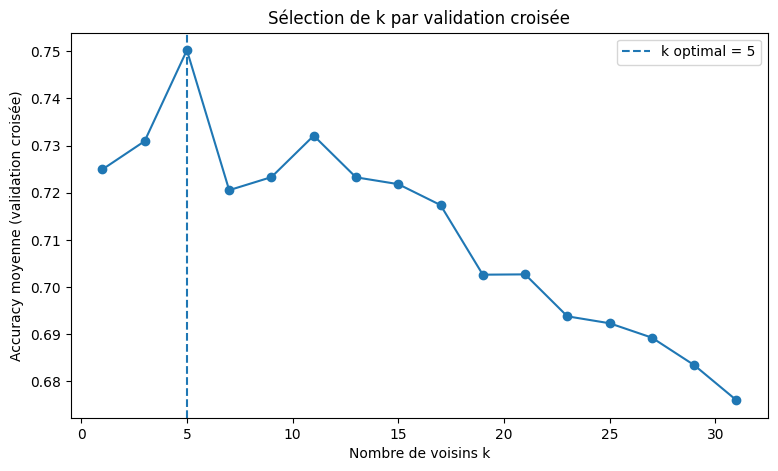

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    results_df["k"],
    results_df["accuracy_mean"],
    marker="o"
)

plt.axvline(
    best_k,
    linestyle="--",
    label=f"k optimal = {best_k}"
)

plt.xlabel("Nombre de voisins k")
plt.ylabel("Accuracy moyenne (validation croisée)")
plt.title("Sélection de k par validation croisée")
plt.legend()
plt.show()

In [23]:
# Pipeline avec la valeur optimale de k
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(
        n_neighbors=best_k
    ))
])

# Entraînement sur tout le training set
final_model.fit(X_train, y_train)

# Prédiction sur le test set
y_pred = final_model.predict(X_test)

In [24]:
from sklearn.metrics import (
    accuracy_score,
    zero_one_loss,
    confusion_matrix,
    classification_report
)

# Accuracy
test_accuracy = accuracy_score(
    y_test,
    y_pred
)

# Erreur de classification
test_error = zero_one_loss(
    y_test,
    y_pred
)

print(f"k final              : {best_k}")
print(f"Accuracy CV          : {best_row['accuracy_mean']:.4f}")
print(f"Erreur CV            : {best_row['error_mean']:.4f}")
print(f"Accuracy test        : {test_accuracy:.4f}")
print(f"Erreur de test       : {test_error:.4f}")

k final              : 5
Accuracy CV          : 0.7502
Erreur CV            : 0.2498
Accuracy test        : 0.7471
Erreur de test       : 0.2529


In [25]:
cm = confusion_matrix(y_test, y_pred)

print("Matrice de confusion :")
print(cm)

Matrice de confusion :
[[42  1  1  0]
 [ 3 20 19  0]
 [ 3 12 28  1]
 [ 2  1  0 37]]


In [26]:
classes = sorted(y.unique())

cm_df = pd.DataFrame(
    cm,
    index=[f"Réel : {c}" for c in classes],
    columns=[f"Prédit : {c}" for c in classes]
)

print(cm_df)

             Prédit : bus  Prédit : opel  Prédit : saab  Prédit : van
Réel : bus             42              1              1             0
Réel : opel             3             20             19             0
Réel : saab             3             12             28             1
Réel : van              2              1              0            37


In [27]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

         bus       0.84      0.95      0.89        44
        opel       0.59      0.48      0.53        42
        saab       0.58      0.64      0.61        44
         van       0.97      0.93      0.95        40

    accuracy                           0.75       170
   macro avg       0.75      0.75      0.74       170
weighted avg       0.74      0.75      0.74       170

